# Recommender Aggregate Spearman Heatmaps

This notebook consumes `evaluation_results/recommender_evaluation_consolidated.json` produced by `evaluate_selected_logreg_recommenders.sbatch` and reproduces the results-only reporting flow: aggregate tables, clustered-vs-secure improvement summaries, and heatmaps.

In [1]:
# !squeue 

In [2]:
from __future__ import annotations

import json
from pathlib import Path

try:
    import matplotlib.colors as mcolors
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "matplotlib is required for this notebook. Install it in the active notebook environment."
    ) from exc

try:
    import numpy as np
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "numpy is required for this notebook. Install it in the active notebook environment."
    ) from exc

try:
    import pandas as pd
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "pandas is required for this notebook. Install it in the active notebook environment."
    ) from exc

from IPython.display import Markdown, display
import re
plt.style.use("default")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)
from datetime import datetime, timezone


In [3]:
candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (
        root
        for root in candidate_roots
        if (root / "federated").exists() and (root / "notebooks").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the repository root. Run this notebook from the repo root or the notebooks directory."
    )

RESULT_SOURCE = "artifacts"  # "consolidated" or "artifacts"
CONSOLIDATED_RESULT_PATH = REPO_ROOT / "evaluation_results" / "recommender_evaluation_consolidated.json"
DIRECT_RUNS_ROOT = REPO_ROOT / "federated" / "runs"
RUN_REFERENCE_PATH = REPO_ROOT / "result_reference" / "run_ids.json"
TARGET_DATASETS = {
    "loan_default": "loan_default",
    "bank_marketing": "bank_marketing",
    "cencus_income": "census_income",
}
MODEL_DATASET_DEFAULTS = {
    "logreg": ["bank_marketing", "cencus_income", "loan_default"],
    "mlp_classifier": ["bank_marketing", "loan_default"],
}
MODEL_PERSONA_DEFAULTS = {
    "logreg": "dirichlet_sampled",
    "mlp_classifier": "lay",
}
MODEL_PERSONA_TYPE_DEFAULTS = {
    "logreg": "dirichlet_sampled",
    "mlp_classifier": "lay",
}
SELECTED_MODEL_NAME = "logreg"
MODEL_PERSONA_TYPE = "lay"
SELECTED_DATASET_KEYS = MODEL_DATASET_DEFAULTS[SELECTED_MODEL_NAME].copy()
if SELECTED_MODEL_NAME not in MODEL_DATASET_DEFAULTS:
    raise ValueError(
        f"Unsupported SELECTED_MODEL_NAME={SELECTED_MODEL_NAME!r}. "
        f"Expected one of {sorted(MODEL_DATASET_DEFAULTS)}."
    )
unknown_dataset_keys = sorted(set(SELECTED_DATASET_KEYS) - set(TARGET_DATASETS))
if unknown_dataset_keys:
    raise ValueError(
        f"Unsupported SELECTED_DATASET_KEYS={unknown_dataset_keys!r}. "
        f"Expected keys drawn from {sorted(TARGET_DATASETS)}."
    )
RUN_REFERENCE_KEYS = [
    f"{dataset_key}_{SELECTED_MODEL_NAME}" for dataset_key in SELECTED_DATASET_KEYS
]
SELECTED_PERSONA = MODEL_PERSONA_DEFAULTS[SELECTED_MODEL_NAME]
SELECTED_PERSONA_TYPE = MODEL_PERSONA_TYPE_DEFAULTS[SELECTED_MODEL_NAME]
DIRECT_SELECTION_ID = "test__max-40__seed-42"
DIRECT_PERSONA = SELECTED_PERSONA
DIRECT_RECOMMENDER_DIRNAME = "svm_rank_fedavg"
AGGREGATION_MODES = ["plain", "secure", "clustered"]
MODE_ORDER = ["secure", "clustered", "plain"]
INCLUDE_PLAIN = False
DISPLAY_MODES = ["secure", "clustered"] + (["plain"] if INCLUDE_PLAIN else [])
MODE_SHORT_LABELS = {
    "secure": "S",
    "clustered": "C",
    "plain": "P",
}
METRICS = [
    ("spearman_at_3", "Spearman@3"),
    ("spearman_at_5", "Spearman@5"),
    ("spearman_at_8", "Spearman@8"),
]
METRIC_KEYS = [metric for metric, _ in METRICS]
LEGACY_METRIC_ALIASES = {
    "spearman": "pearson",
    "spearman_at_1": "pearson_at_1",
    "spearman_at_3": "pearson_at_3",
    "spearman_at_5": "pearson_at_5",
    "spearman_at_8": "pearson_at_8",
}
IMPROVEMENT_TARGET_MODE = "clustered"
IMPROVEMENT_BASELINE_MODE = "secure"

RUN_ID_PATTERN = re.compile(
    r"^federated-training-"
    r"(?P<dataset>.+)-"
    r"(?P<timestamp>\d{8}t\d+\+\d{4})-"
    r"(?P<model>.+)-"
    r"(?P<clients>\d+)clients-"
    r"alpha(?P<alpha>[^-]+)-"
    r"seed(?P<seed>\d+)-"
    r"(?P<suffix>[0-9a-f]+)$"
)


def load_json(path: Path) -> dict[str, object]:
    return json.loads(path.read_text(encoding="utf-8"))


def load_payload(path: Path) -> dict[str, object]:
    if not path.exists():
        raise FileNotFoundError(
            f"Consolidated evaluation result not found: {path}. Generate it first or switch RESULT_SOURCE to 'artifacts'."
        )
    return load_json(path)


def parse_run_id(run_id: str) -> dict[str, object]:
    match = RUN_ID_PATTERN.match(run_id)
    if match is None:
        raise ValueError(f"Unexpected run_id format: {run_id}")
    groups = match.groupdict()
    dataset_key = groups["dataset"]
    alpha_text = groups["alpha"]
    return {
        "dataset_key": dataset_key,
        "dataset_name": TARGET_DATASETS.get(dataset_key, dataset_key),
        "model_name": groups["model"],
        "num_clients": int(groups["clients"]),
        "alpha": float(alpha_text),
        "alpha_text": alpha_text,
        "seed": int(groups["seed"]),
    }


def _normalized_metric_value(payload: dict[str, object], metric: str) -> float | None:
    value = payload.get(metric)
    if value is None:
        legacy_metric = LEGACY_METRIC_ALIASES.get(metric)
        if legacy_metric is not None:
            value = payload.get(legacy_metric)
    return float(value) if isinstance(value, (int, float)) else None


def client_metrics_from_summary(summary: dict[str, object]) -> dict[str, dict[str, float | None]]:
    metrics: dict[str, dict[str, float | None]] = {}
    for client in summary.get("clients", []):
        client_id = str(client["client_id"])
        metrics[client_id] = {
            "spearman_at_3": _normalized_metric_value(client, "spearman_at_3"),
            "spearman_at_5": _normalized_metric_value(client, "spearman_at_5"),
            "spearman_at_8": _normalized_metric_value(client, "spearman_at_8"),
        }
    return dict(sorted(metrics.items()))


def aggregate_metrics_from_summary(summary: dict[str, object]) -> dict[str, float | None]:
    aggregate = summary.get("aggregate", {})
    if not isinstance(aggregate, dict):
        return {}
    normalized = {
        str(key): float(value) if isinstance(value, (int, float)) else None
        for key, value in aggregate.items()
    }
    for metric in ["spearman", "spearman_at_1", *METRIC_KEYS]:
        if normalized.get(metric) is None:
            legacy_metric = LEGACY_METRIC_ALIASES.get(metric)
            legacy_value = aggregate.get(legacy_metric) if legacy_metric is not None else None
            if isinstance(legacy_value, (int, float)):
                normalized[metric] = float(legacy_value)
    return normalized


def load_reference_run_ids(reference_path: Path, reference_keys: list[str]) -> list[str]:
    if not reference_path.exists():
        return []
    payload = load_json(reference_path)
    run_ids: list[str] = []
    for key in reference_keys:
        entry = payload.get(key)
        if not isinstance(entry, dict):
            continue
        values = entry.get("run_ids")
        if isinstance(values, list):
            run_ids.extend(str(value) for value in values)
    return sorted(dict.fromkeys(run_ids))


def discover_direct_run_ids() -> list[str]:
    referenced = load_reference_run_ids(RUN_REFERENCE_PATH, RUN_REFERENCE_KEYS)
    if referenced:
        return referenced
    run_ids: list[str] = []
    for dataset_key in SELECTED_DATASET_KEYS:
        pattern = f"federated-training-{dataset_key}-*-{SELECTED_MODEL_NAME}-*"
        run_ids.extend(path.name for path in DIRECT_RUNS_ROOT.glob(pattern) if path.is_dir())
    return sorted(dict.fromkeys(run_ids))


def evaluation_summary_path(run_id: str, mode: str) -> Path:
    return (
        DIRECT_RUNS_ROOT
        / run_id
        / "recommender_training"
        / DIRECT_SELECTION_ID
        / DIRECT_PERSONA
        / DIRECT_RECOMMENDER_DIRNAME
        / mode
        / "evaluation_summary.json"
    )


def build_payload_from_artifacts(run_ids: list[str]) -> dict[str, object]:
    dataset_entries: dict[str, dict[str, dict[str, object]]] = {
        TARGET_DATASETS[dataset_key]: {} for dataset_key in SELECTED_DATASET_KEYS
    }

    for run_id in run_ids:
        parsed = parse_run_id(run_id)
        if parsed["model_name"] != SELECTED_MODEL_NAME:
            continue
        if parsed["dataset_key"] not in SELECTED_DATASET_KEYS:
            continue
        dataset_name = str(parsed["dataset_name"])
        federated_config = f"{parsed['num_clients']}clients-alpha{parsed['alpha_text']}"
        config_key = f"{run_id}::{federated_config}"
        config_entry = dataset_entries[dataset_name].setdefault(
            config_key,
            {
                "runid": run_id,
                "federated_config": federated_config,
                "num_clients": parsed["num_clients"],
                "alpha": parsed["alpha"],
                "alpha_text": parsed["alpha_text"],
                "seed": parsed["seed"],
                "model_name": parsed["model_name"],
                "selection_id": DIRECT_SELECTION_ID,
                "persona": SELECTED_PERSONA_TYPE,
                "recommender_type": "svm_rank",
                "training_variant": None,
                "aggregations": {},
            },
        )

        for mode in AGGREGATION_MODES:
            summary_path = evaluation_summary_path(run_id, mode)
            if not summary_path.exists():
                continue
            summary = load_json(summary_path)
            config_entry["aggregations"][mode] = {
                "client_count": summary.get("client_count"),
                "source_path": str(summary_path.relative_to(REPO_ROOT)),
                "aggregate": aggregate_metrics_from_summary(summary),
                "clients": client_metrics_from_summary(summary),
            }
            if config_entry.get("training_variant") is None:
                config_entry["training_variant"] = summary.get("training_variant")
            if config_entry.get("recommender_type") in {None, "svm_rank"}:
                config_entry["recommender_type"] = summary.get("recommender_type") or config_entry.get("recommender_type")

    finalized_datasets: dict[str, list[dict[str, object]]] = {}
    for dataset_name, configs in dataset_entries.items():
        entries = [entry for entry in configs.values() if entry.get("aggregations")]
        entries.sort(key=lambda item: (item["num_clients"], item["alpha"], item["runid"]))
        finalized_datasets[dataset_name] = entries

    return {
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "output_path": None,
        "dataset_count": len(finalized_datasets),
        "config_count": sum(len(entries) for entries in finalized_datasets.values()),
        "aggregation_modes": list(AGGREGATION_MODES),
        "datasets": finalized_datasets,
    }


def build_run_results(payload: dict[str, object]) -> tuple[pd.DataFrame, pd.DataFrame]:
    run_rows: list[dict[str, object]] = []
    client_rows: list[dict[str, object]] = []
    datasets = payload.get("datasets", {})
    if not isinstance(datasets, dict):
        raise ValueError("Expected 'datasets' to be a dictionary.")

    for dataset_name, entries in datasets.items():
        if not isinstance(entries, list):
            continue
        for entry in entries:
            if not isinstance(entry, dict):
                continue
            run_id = str(entry.get("runid"))
            base = {
                "dataset": str(dataset_name),
                "run_id": run_id,
                "federated_config": entry.get("federated_config"),
                "client_count": int(entry.get("num_clients")),
                "alpha": float(entry.get("alpha")),
                "alpha_label": str(entry.get("alpha_text")),
                "seed": int(entry.get("seed")),
                "model_name": str(entry.get("model_name")),
                "selection_id": entry.get("selection_id"),
                "persona": entry.get("persona"),
                "recommender_type": entry.get("recommender_type"),
                "training_variant": entry.get("training_variant"),
            }
            if base["model_name"] != SELECTED_MODEL_NAME:
                continue
            if dataset_name not in {TARGET_DATASETS[key] for key in SELECTED_DATASET_KEYS}:
                continue
            aggregations = entry.get("aggregations", {})
            if not isinstance(aggregations, dict):
                continue
            for mode, mode_entry in aggregations.items():
                if not isinstance(mode_entry, dict):
                    continue
                client_metrics = mode_entry.get("clients", {})
                stored_aggregate = mode_entry.get("aggregate", {})
                aggregate_metrics = {metric: [] for metric in METRIC_KEYS}
                if isinstance(client_metrics, dict):
                    for client_id, metrics in client_metrics.items():
                        if not isinstance(metrics, dict):
                            continue
                        client_row = {
                            **base,
                            "mode": str(mode),
                            "artifact_path": mode_entry.get("source_path"),
                            "client_id": str(client_id),
                        }
                        for metric in METRIC_KEYS:
                            value = metrics.get(metric)
                            client_row[metric] = float(value) if value is not None else np.nan
                            if value is not None:
                                aggregate_metrics[metric].append(float(value))
                        client_rows.append(client_row)
                run_row = {
                    **base,
                    "mode": str(mode),
                    "artifact_path": mode_entry.get("source_path"),
                    "reported_client_count": mode_entry.get("client_count"),
                }
                for metric in METRIC_KEYS:
                    stored_value = stored_aggregate.get(metric) if isinstance(stored_aggregate, dict) else None
                    if stored_value is not None:
                        run_row[metric] = float(stored_value)
                    else:
                        values = aggregate_metrics[metric]
                        run_row[metric] = float(np.mean(values)) if values else np.nan
                run_rows.append(run_row)

    run_df = pd.DataFrame(run_rows)
    client_df = pd.DataFrame(client_rows)
    if not run_df.empty:
        run_df = run_df.sort_values(["dataset", "client_count", "alpha", "run_id", "mode"]).reset_index(drop=True)
    if not client_df.empty:
        client_df = client_df.sort_values(["dataset", "client_count", "alpha", "run_id", "mode", "client_id"]).reset_index(drop=True)
    return run_df, client_df


if RESULT_SOURCE == "consolidated":
    payload = load_payload(CONSOLIDATED_RESULT_PATH)
    source_description = f"consolidated results from `{CONSOLIDATED_RESULT_PATH.relative_to(REPO_ROOT)}`"
elif RESULT_SOURCE == "artifacts":
    direct_run_ids = discover_direct_run_ids()
    payload = build_payload_from_artifacts(direct_run_ids)
    source_description = (
        f"direct training artifacts under `{DIRECT_RUNS_ROOT.relative_to(REPO_ROOT)}` "
        f"for `{len(direct_run_ids)}` run IDs"
    )
else:
    raise ValueError("RESULT_SOURCE must be 'consolidated' or 'artifacts'.")

run_results, raw_client_results = build_run_results(payload)

display(Markdown(f"Loaded results from {source_description}."))
display(Markdown(
    f"Selected model: `{SELECTED_MODEL_NAME}`. Selected datasets: {', '.join(f'`{key}`' for key in SELECTED_DATASET_KEYS)}."
))
display(Markdown(
    f"Loaded `{len(run_results)}` run/mode summaries across `{run_results['run_id'].nunique() if not run_results.empty else 0}` run IDs."
))
display(Markdown(
    f"Loaded `{len(raw_client_results)}` raw per-client score rows across `{raw_client_results['run_id'].nunique() if not raw_client_results.empty else 0}` run IDs."
))

run_results.head()


Loaded results from direct training artifacts under `federated/runs` for `32` run IDs.

Selected model: `logreg`. Selected datasets: `bank_marketing`, `cencus_income`, `loan_default`.

Loaded `96` run/mode summaries across `32` run IDs.

Loaded `900` raw per-client score rows across `32` run IDs.

,dataset,run_id,federated_config,client_count,alpha,alpha_label,seed,model_name,selection_id,persona,recommender_type,training_variant,mode,artifact_path,reported_client_count,spearman_at_3,spearman_at_5,spearman_at_8
0,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.1,5,0.1,0.1,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,clustered,federated/runs/federated-training-bank_marketi...,5,0.613910,0.650500,0.729577
1,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.1,5,0.1,0.1,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,plain,federated/runs/federated-training-bank_marketi...,5,0.496056,0.618453,0.717526
2,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.1,5,0.1,0.1,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,secure,federated/runs/federated-training-bank_marketi...,5,0.496056,0.618453,0.717526
3,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.3,5,0.3,0.3,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,clustered,federated/runs/federated-training-bank_marketi...,5,0.545674,0.586570,0.714151
4,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.3,5,0.3,0.3,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,plain,federated/runs/federated-training-bank_marketi...,5,0.553996,0.604313,0.665723


In [4]:
def aggregate_results(results: pd.DataFrame) -> pd.DataFrame:
    if results.empty:
        return results.copy()
    grouped = (
        results.groupby(["dataset", "client_count", "alpha", "alpha_label", "mode"], as_index=False)
        .agg(
            run_count=("run_id", "nunique"),
            spearman_at_3=("spearman_at_3", "mean"),
            spearman_at_5=("spearman_at_5", "mean"),
            spearman_at_8=("spearman_at_8", "mean"),
        )
        .sort_values(["dataset", "client_count", "alpha", "mode"])
        .reset_index(drop=True)
    )
    return grouped


def load_clustered_improvements(client_results: pd.DataFrame) -> pd.DataFrame:
    if client_results.empty:
        return pd.DataFrame()

    rows: list[dict[str, object]] = []
    join_keys = ["dataset", "run_id", "client_count", "alpha", "alpha_label", "seed", "client_id"]
    for (dataset, run_id), group in client_results.groupby(["dataset", "run_id"], sort=True):
        baseline_df = group.loc[group["mode"] == IMPROVEMENT_BASELINE_MODE, join_keys + METRIC_KEYS]
        target_df = group.loc[group["mode"] == IMPROVEMENT_TARGET_MODE, join_keys + METRIC_KEYS]
        if baseline_df.empty or target_df.empty:
            continue
        baseline_df = baseline_df.rename(columns={metric: f"{IMPROVEMENT_BASELINE_MODE}_{metric}" for metric in METRIC_KEYS})
        target_df = target_df.rename(columns={metric: f"{IMPROVEMENT_TARGET_MODE}_{metric}" for metric in METRIC_KEYS})
        merged = baseline_df.merge(target_df, on=join_keys, how="inner")
        if merged.empty:
            continue
        for metric, metric_label in METRICS:
            baseline_column = f"{IMPROVEMENT_BASELINE_MODE}_{metric}"
            target_column = f"{IMPROVEMENT_TARGET_MODE}_{metric}"
            comparable = merged[[baseline_column, target_column]].dropna()
            improved_count = int((comparable[target_column] > comparable[baseline_column]).sum())
            tied_count = int((comparable[target_column] == comparable[baseline_column]).sum())
            worse_count = int((comparable[target_column] < comparable[baseline_column]).sum())
            comparable_client_count = int(len(comparable))
            improved_pct = 100.0 * improved_count / comparable_client_count if comparable_client_count > 0 else np.nan
            rows.append(
                {
                    "dataset": dataset,
                    "run_id": run_id,
                    "client_count": int(merged.iloc[0]["client_count"]),
                    "alpha": float(merged.iloc[0]["alpha"]),
                    "alpha_label": str(merged.iloc[0]["alpha_label"]),
                    "seed": int(merged.iloc[0]["seed"]),
                    "metric": metric,
                    "metric_label": metric_label,
                    "comparison": f"{IMPROVEMENT_TARGET_MODE}_over_{IMPROVEMENT_BASELINE_MODE}",
                    "improved_count": improved_count,
                    "tied_count": tied_count,
                    "worse_count": worse_count,
                    "comparable_client_count": comparable_client_count,
                    "improved_pct": improved_pct,
                }
            )
    return pd.DataFrame(rows)


def aggregate_clustered_improvements(improvements: pd.DataFrame) -> pd.DataFrame:
    if improvements.empty:
        return improvements.copy()
    grouped = (
        improvements.groupby(["dataset", "client_count", "alpha", "alpha_label", "metric", "metric_label", "comparison"], as_index=False)
        .agg(
            run_count=("run_id", "nunique"),
            improved_count=("improved_count", "sum"),
            tied_count=("tied_count", "sum"),
            worse_count=("worse_count", "sum"),
            comparable_client_count=("comparable_client_count", "sum"),
        )
        .sort_values(["dataset", "client_count", "alpha", "metric"])
        .reset_index(drop=True)
    )
    grouped["improved_pct"] = np.where(
        grouped["comparable_client_count"] > 0,
        100.0 * grouped["improved_count"] / grouped["comparable_client_count"],
        np.nan,
    )
    return grouped


aggregated_results = aggregate_results(run_results)
clustered_improvements = load_clustered_improvements(raw_client_results)
aggregated_clustered_improvements = aggregate_clustered_improvements(clustered_improvements)

display(Markdown(
    f"Computed per-client improvement rates for `{IMPROVEMENT_TARGET_MODE}` over `{IMPROVEMENT_BASELINE_MODE}` across `{clustered_improvements['run_id'].nunique() if not clustered_improvements.empty else 0}` run IDs. for dataset trained by `{SELECTED_MODEL_NAME}`"
))

aggregated_results.to_csv("./result_logreg_updated.csv")
aggregated_results.head(32)

Computed per-client improvement rates for `clustered` over `secure` across `32` run IDs. for dataset trained by `logreg`

,dataset,client_count,alpha,alpha_label,mode,run_count,spearman_at_3,spearman_at_5,spearman_at_8
0,bank_marketing,5,0.1,0.1,clustered,1,0.613910,0.650500,0.729577
1,bank_marketing,5,0.1,0.1,plain,1,0.496056,0.618453,0.717526
2,bank_marketing,5,0.1,0.1,secure,1,0.496056,0.618453,0.717526
3,bank_marketing,5,0.3,0.3,clustered,1,0.545674,0.586570,0.714151
4,bank_marketing,5,0.3,0.3,plain,1,0.553996,0.604313,0.665723
5,bank_marketing,5,0.3,0.3,secure,1,0.553996,0.604313,0.665723
6,bank_marketing,5,1.0,1.0,clustered,1,0.624951,0.654210,0.732734
7,bank_marketing,5,1.0,1.0,plain,1,0.601611,0.677206,0.704806
8,bank_marketing,5,1.0,1.0,secure,1,0.601611,0.677206,0.704806
9,bank_marketing,5,10.0,10.0,clustered,1,0.587837,0.641344,0.742995


## bank_marketing

### bank_marketing: Spearman@3

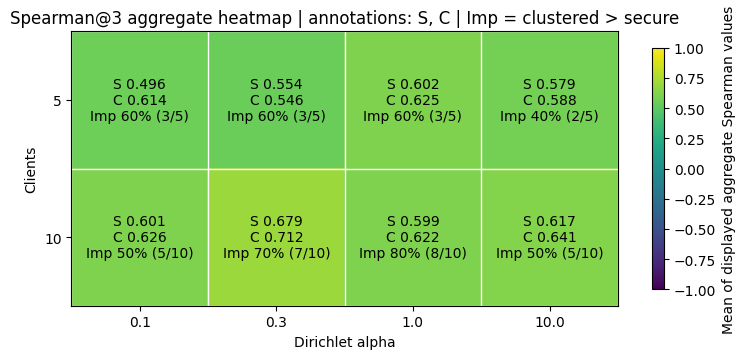

### bank_marketing: Spearman@5

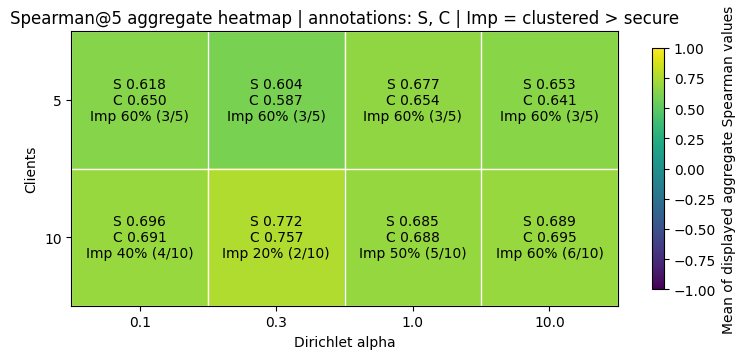

### bank_marketing: Spearman@8

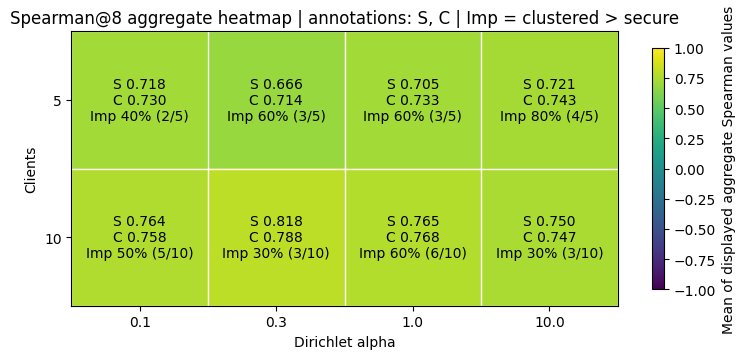

## census_income

### census_income: Spearman@3

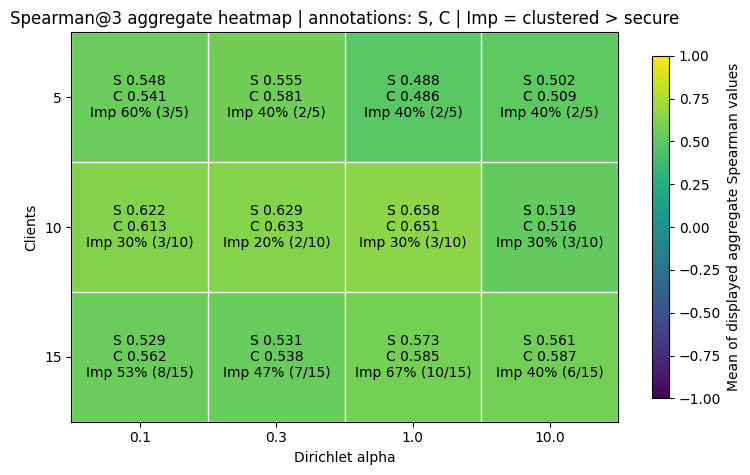

### census_income: Spearman@5

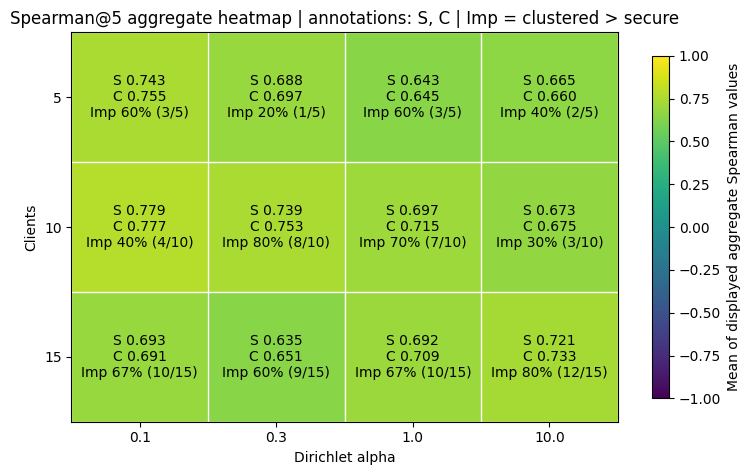

### census_income: Spearman@8

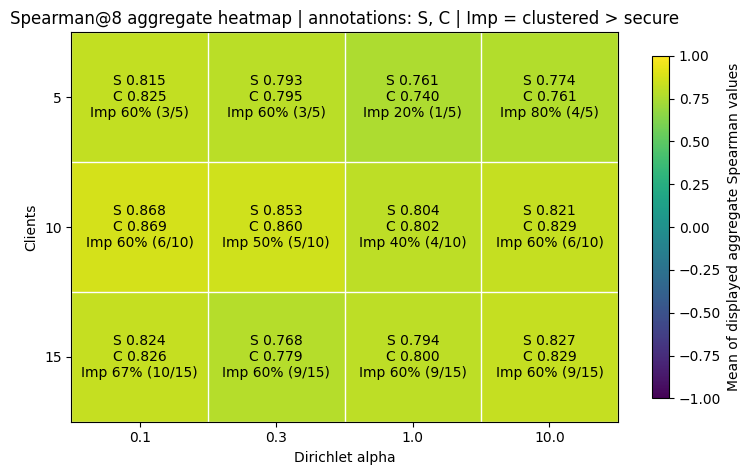

## loan_default

### loan_default: Spearman@3

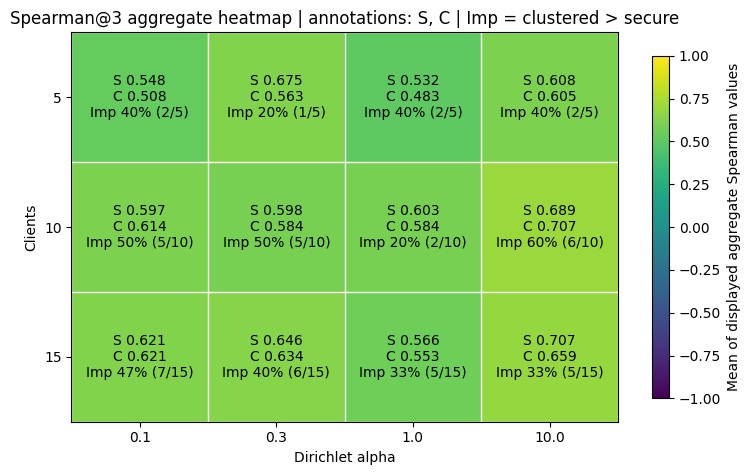

### loan_default: Spearman@5

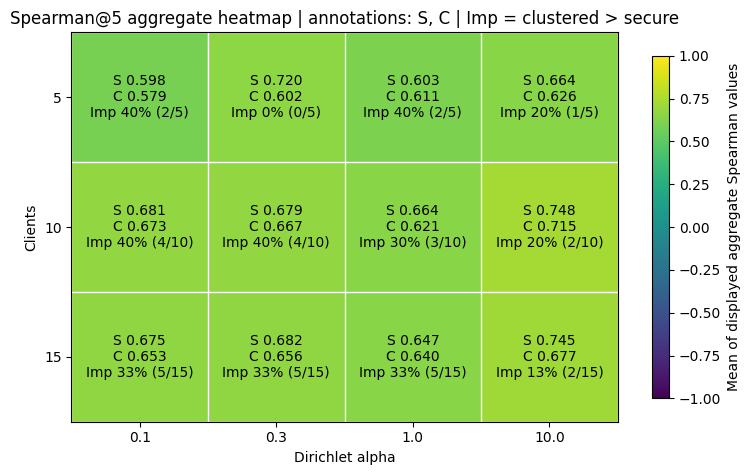

### loan_default: Spearman@8

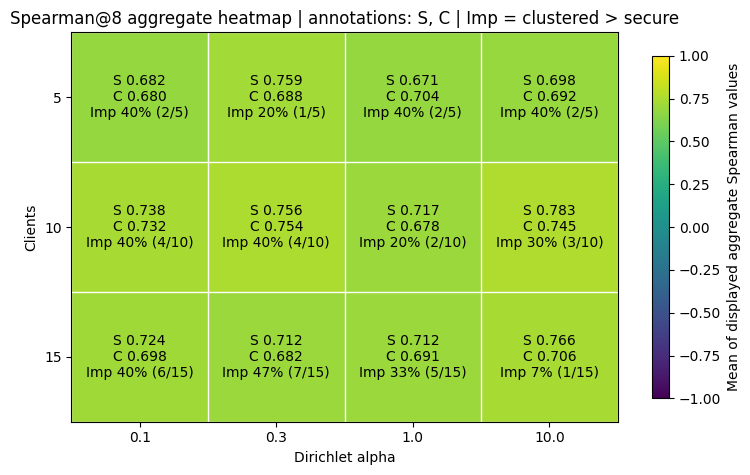

In [5]:
def build_heatmap_payload(
    results: pd.DataFrame,
    improvements: pd.DataFrame,
    dataset_name: str,
    metric: str,
    display_modes: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    dataset_results = results.loc[results["dataset"] == dataset_name].copy()
    dataset_improvements = improvements.loc[improvements["dataset"] == dataset_name].copy()
    if dataset_results.empty:
        return pd.DataFrame(dtype=float), pd.DataFrame(dtype=object)

    client_levels = sorted(dataset_results["client_count"].unique())
    alpha_rows = (
        dataset_results[["alpha", "alpha_label"]]
        .drop_duplicates()
        .sort_values("alpha")
        .reset_index(drop=True)
    )
    alpha_levels = alpha_rows["alpha"].tolist()
    alpha_tick_labels = alpha_rows["alpha_label"].tolist()

    color_df = pd.DataFrame(np.nan, index=client_levels, columns=alpha_levels, dtype=float)
    annotation_df = pd.DataFrame("", index=client_levels, columns=alpha_levels, dtype=object)

    for client_count in client_levels:
        for alpha in alpha_levels:
            cell = dataset_results[(dataset_results["client_count"] == client_count) & (dataset_results["alpha"] == alpha)]
            improvement_row = dataset_improvements[
                (dataset_improvements["client_count"] == client_count)
                & (dataset_improvements["alpha"] == alpha)
                & (dataset_improvements["metric"] == metric)
            ]
            values = []
            lines = []
            for mode in display_modes:
                mode_row = cell[cell["mode"] == mode]
                if mode_row.empty:
                    lines.append(f"{MODE_SHORT_LABELS[mode]} --")
                    continue
                value = float(mode_row.iloc[0][metric])
                if np.isnan(value):
                    lines.append(f"{MODE_SHORT_LABELS[mode]} --")
                    continue
                values.append(value)
                lines.append(f"{MODE_SHORT_LABELS[mode]} {value:.3f}")
            if improvement_row.empty:
                lines.append("Imp --")
            else:
                improved_pct = float(improvement_row.iloc[0]["improved_pct"])
                improved_count = int(improvement_row.iloc[0]["improved_count"])
                comparable_client_count = int(improvement_row.iloc[0]["comparable_client_count"])
                if np.isnan(improved_pct) or comparable_client_count == 0:
                    lines.append("Imp --")
                else:
                    lines.append(f"Imp {improved_pct:.0f}% ({improved_count}/{comparable_client_count})")
            color_df.loc[client_count, alpha] = float(np.mean(values)) if values else np.nan
            annotation_df.loc[client_count, alpha] = "\n".join(lines)

    color_df.columns = alpha_tick_labels
    annotation_df.columns = alpha_tick_labels
    return color_df, annotation_df


def text_color_for_value(value: float, norm: mcolors.Normalize, cmap) -> str:
    if np.isnan(value):
        return "#444444"
    red, green, blue, _ = cmap(norm(value))
    luminance = 0.299 * red + 0.587 * green + 0.114 * blue
    return "white" if luminance < 0.5 else "black"


def plot_metric_heatmap(
    results: pd.DataFrame,
    improvements: pd.DataFrame,
    dataset_name: str,
    metric: str,
    metric_label: str,
    display_modes: list[str],
) -> None:
    color_df, annotation_df = build_heatmap_payload(results, improvements, dataset_name, metric, display_modes)
    display(Markdown(f"### {dataset_name}: {metric_label}"))
    if color_df.empty:
        display(Markdown("_No aggregate results were loaded for this dataset/metric._"))
        return

    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(color="#f3f3f3")
    norm = mcolors.Normalize(vmin=-1.0, vmax=1.0)
    matrix = np.ma.masked_invalid(color_df.to_numpy(dtype=float))

    fig, ax = plt.subplots(figsize=(1.8 + 1.45 * color_df.shape[1], 1.4 + 1.15 * color_df.shape[0]))
    image = ax.imshow(matrix, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(np.arange(color_df.shape[1]))
    ax.set_xticklabels(color_df.columns, rotation=0)
    ax.set_yticks(np.arange(color_df.shape[0]))
    ax.set_yticklabels([str(value) for value in color_df.index])
    ax.set_xlabel("Dirichlet alpha")
    ax.set_ylabel("Clients")
    mode_caption = ", ".join(MODE_SHORT_LABELS[mode] for mode in display_modes)
    ax.set_title(
        f"{metric_label} aggregate heatmap | annotations: {mode_caption} | Imp = {IMPROVEMENT_TARGET_MODE} > {IMPROVEMENT_BASELINE_MODE}"
    )

    ax.set_xticks(np.arange(-0.5, color_df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, color_df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    for row_idx in range(color_df.shape[0]):
        for col_idx in range(color_df.shape[1]):
            annotation = annotation_df.iat[row_idx, col_idx]
            value = color_df.iat[row_idx, col_idx]
            ax.text(
                col_idx,
                row_idx,
                annotation,
                ha="center",
                va="center",
                fontsize=10,
                color=text_color_for_value(value, norm, cmap),
            )

    colorbar = fig.colorbar(image, ax=ax, shrink=0.88)
    colorbar.set_label("Mean of displayed aggregate Spearman values")

    plt.tight_layout()
    plt.show()


for dataset_name in sorted(aggregated_results["dataset"].unique()) if not aggregated_results.empty else []:
    display(Markdown(f"## {dataset_name}"))
    for metric, metric_label in METRICS:
        plot_metric_heatmap(
            aggregated_results,
            aggregated_clustered_improvements,
            dataset_name,
            metric,
            metric_label,
            DISPLAY_MODES,
        )


## Weighted Delta Diagnostics

These diagnostics use the weighted aggregate metrics saved in each evaluation summary. Positive deltas mean clustered outperformed secure; negative deltas mean secure outperformed clustered.

## Weighted Delta Heatmaps: bank_marketing

### bank_marketing: Weighted Delta Spearman@3 (clustered - secure)

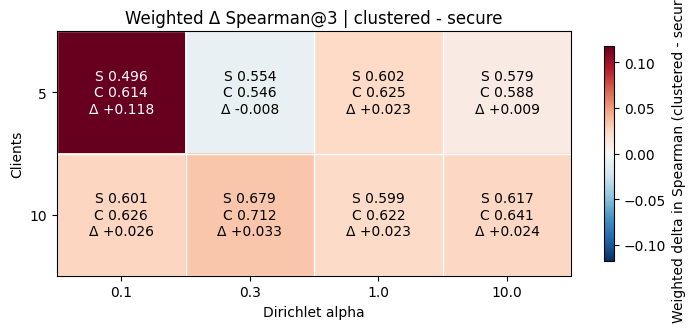

### bank_marketing: Weighted Delta Spearman@5 (clustered - secure)

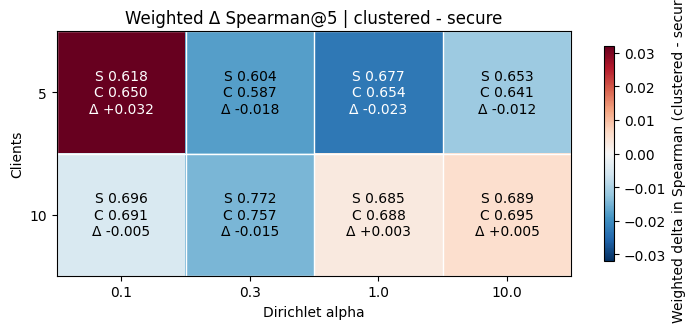

### bank_marketing: Weighted Delta Spearman@8 (clustered - secure)

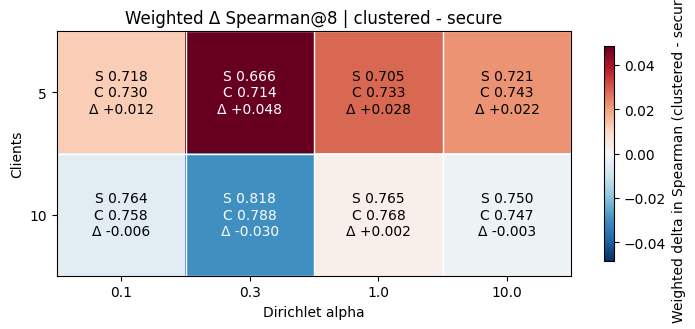

## Weighted Delta Heatmaps: census_income

### census_income: Weighted Delta Spearman@3 (clustered - secure)

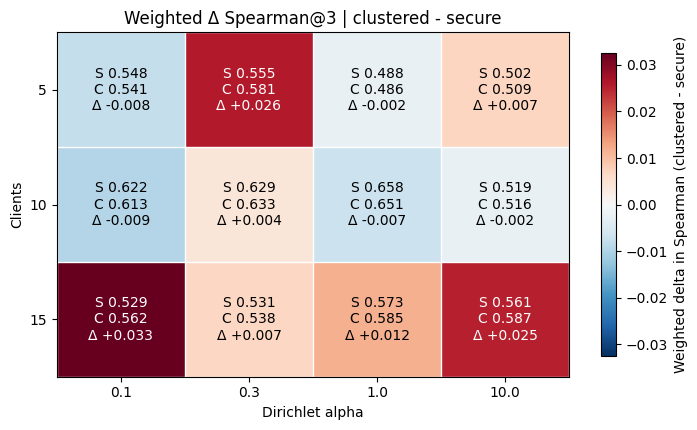

### census_income: Weighted Delta Spearman@5 (clustered - secure)

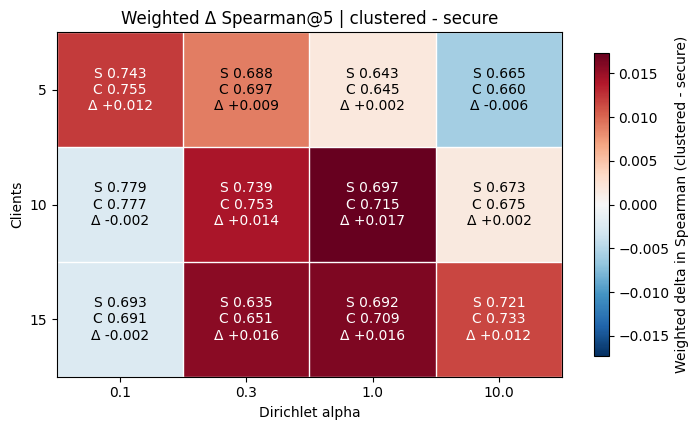

### census_income: Weighted Delta Spearman@8 (clustered - secure)

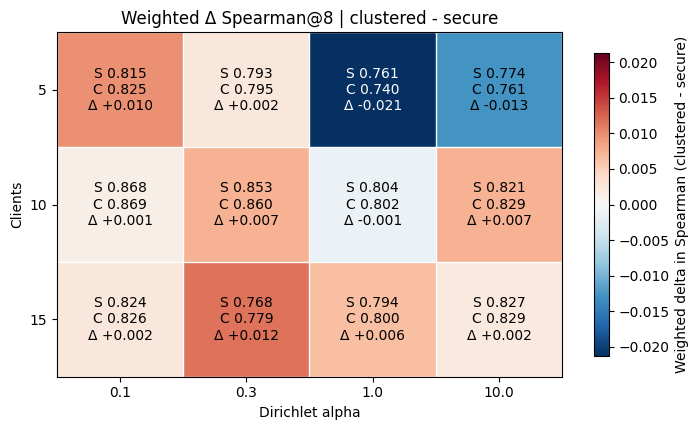

## Weighted Delta Heatmaps: loan_default

### loan_default: Weighted Delta Spearman@3 (clustered - secure)

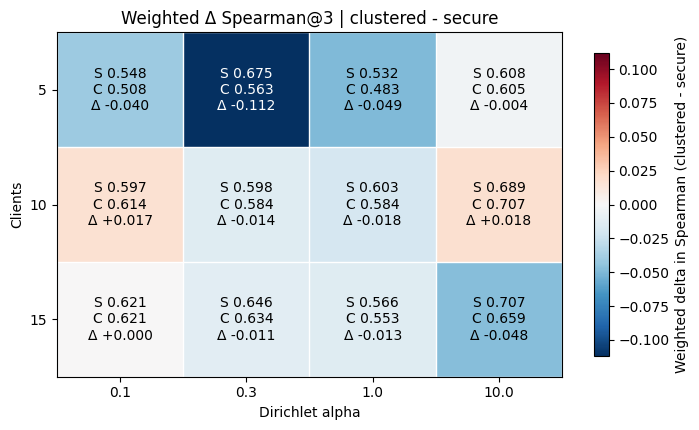

### loan_default: Weighted Delta Spearman@5 (clustered - secure)

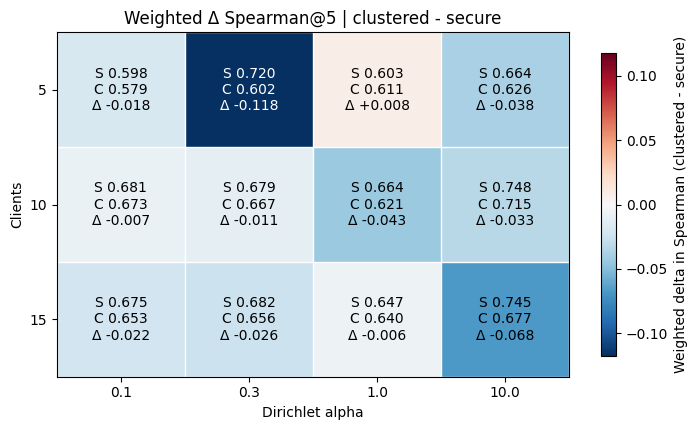

### loan_default: Weighted Delta Spearman@8 (clustered - secure)

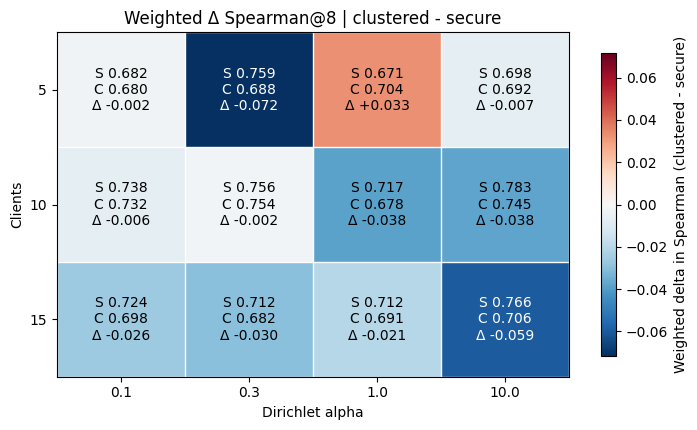

In [6]:
def build_weighted_delta_table(results: pd.DataFrame) -> pd.DataFrame:
    if results.empty:
        return pd.DataFrame()

    rows: list[dict[str, object]] = []
    group_keys = ["dataset", "client_count", "alpha", "alpha_label"]
    for keys, group in results.groupby(group_keys, sort=True):
        secure_row = group.loc[group["mode"] == IMPROVEMENT_BASELINE_MODE]
        clustered_row = group.loc[group["mode"] == IMPROVEMENT_TARGET_MODE]
        if secure_row.empty or clustered_row.empty:
            continue
        secure_row = secure_row.iloc[0]
        clustered_row = clustered_row.iloc[0]
        row = {
            "dataset": keys[0],
            "client_count": int(keys[1]),
            "alpha": float(keys[2]),
            "alpha_label": str(keys[3]),
        }
        for metric, _ in METRICS:
            secure_value = float(secure_row[metric]) if pd.notna(secure_row[metric]) else np.nan
            clustered_value = float(clustered_row[metric]) if pd.notna(clustered_row[metric]) else np.nan
            row[f"secure_{metric}"] = secure_value
            row[f"clustered_{metric}"] = clustered_value
            row[f"delta_{metric}"] = clustered_value - secure_value if pd.notna(secure_value) and pd.notna(clustered_value) else np.nan
        rows.append(row)

    return pd.DataFrame(rows).sort_values(["dataset", "client_count", "alpha"]).reset_index(drop=True)


weighted_delta_table = build_weighted_delta_table(aggregated_results)


def plot_weighted_delta_heatmap(delta_table: pd.DataFrame, dataset_name: str, metric: str, metric_label: str) -> None:
    dataset_delta = delta_table.loc[delta_table["dataset"] == dataset_name].copy()
    display(Markdown(f"### {dataset_name}: Weighted Delta {metric_label} ({IMPROVEMENT_TARGET_MODE} - {IMPROVEMENT_BASELINE_MODE})"))
    if dataset_delta.empty:
        display(Markdown("_No weighted delta data were loaded for this dataset._"))
        return

    client_levels = sorted(dataset_delta["client_count"].unique())
    alpha_rows = (
        dataset_delta[["alpha", "alpha_label"]]
        .drop_duplicates()
        .sort_values("alpha")
        .reset_index(drop=True)
    )
    alpha_levels = alpha_rows["alpha"].tolist()
    alpha_tick_labels = alpha_rows["alpha_label"].tolist()

    delta_column = f"delta_{metric}"
    secure_column = f"secure_{metric}"
    clustered_column = f"clustered_{metric}"

    color_df = pd.DataFrame(np.nan, index=client_levels, columns=alpha_levels, dtype=float)
    annotation_df = pd.DataFrame("", index=client_levels, columns=alpha_levels, dtype=object)

    for client_count in client_levels:
        for alpha in alpha_levels:
            cell = dataset_delta[(dataset_delta["client_count"] == client_count) & (dataset_delta["alpha"] == alpha)]
            if cell.empty:
                continue
            row = cell.iloc[0]
            delta_value = float(row[delta_column]) if pd.notna(row[delta_column]) else np.nan
            secure_value = float(row[secure_column]) if pd.notna(row[secure_column]) else np.nan
            clustered_value = float(row[clustered_column]) if pd.notna(row[clustered_column]) else np.nan
            color_df.loc[client_count, alpha] = delta_value
            annotation_df.loc[client_count, alpha] = "\n".join([
                f"S {secure_value:.3f}" if pd.notna(secure_value) else "S --",
                f"C {clustered_value:.3f}" if pd.notna(clustered_value) else "C --",
                f"Δ {delta_value:+.3f}" if pd.notna(delta_value) else "Δ --",
            ])

    color_df.columns = alpha_tick_labels
    annotation_df.columns = alpha_tick_labels

    vmax = float(np.nanmax(np.abs(color_df.to_numpy(dtype=float)))) if not np.isnan(color_df.to_numpy(dtype=float)).all() else 1.0
    vmax = max(vmax, 1e-6)
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad(color="#f3f3f3")
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    matrix = np.ma.masked_invalid(color_df.to_numpy(dtype=float))

    fig, ax = plt.subplots(figsize=(1.8 + 1.35 * color_df.shape[1], 1.4 + 1.0 * color_df.shape[0]))
    image = ax.imshow(matrix, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(np.arange(color_df.shape[1]))
    ax.set_xticklabels(color_df.columns, rotation=0)
    ax.set_yticks(np.arange(color_df.shape[0]))
    ax.set_yticklabels([str(value) for value in color_df.index])
    ax.set_xlabel("Dirichlet alpha")
    ax.set_ylabel("Clients")
    ax.set_title(f"Weighted Δ {metric_label} | clustered - secure")

    ax.set_xticks(np.arange(-0.5, color_df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, color_df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    for row_idx in range(color_df.shape[0]):
        for col_idx in range(color_df.shape[1]):
            annotation = annotation_df.iat[row_idx, col_idx]
            value = color_df.iat[row_idx, col_idx]
            ax.text(
                col_idx,
                row_idx,
                annotation,
                ha="center",
                va="center",
                fontsize=10,
                color=text_color_for_value(value if pd.notna(value) else 0.0, norm, cmap),
            )

    colorbar = fig.colorbar(image, ax=ax, shrink=0.88)
    colorbar.set_label("Weighted delta in Spearman (clustered - secure)")

    plt.tight_layout()
    plt.show()


display(Markdown("## Weighted Delta Diagnostics"))
display(Markdown(
    "These diagnostics use the weighted aggregate metrics saved in each evaluation summary. "
    "Positive deltas mean clustered outperformed secure; negative deltas mean secure outperformed clustered."
))
weighted_delta_table

for dataset_name in sorted(weighted_delta_table["dataset"].unique()) if not weighted_delta_table.empty else []:
    display(Markdown(f"## Weighted Delta Heatmaps: {dataset_name}"))
    for metric, metric_label in METRICS:
        plot_weighted_delta_heatmap(weighted_delta_table, dataset_name, metric, metric_label)


In [7]:
display(Markdown("## Aggregated Results Table"))
aggregated_results.sort_values(["dataset", "client_count", "alpha", "mode"]).reset_index(drop=True)

display(Markdown("## Clustered Improvement Table"))
aggregated_clustered_improvements.sort_values(["dataset", "metric", "client_count", "alpha"]).reset_index(drop=True)

display(Markdown("## Raw Client Scores"))
raw_client_results.sort_values(["dataset", "client_count", "alpha", "run_id", "mode", "client_id"]).reset_index(drop=True)


## Aggregated Results Table

## Clustered Improvement Table

## Raw Client Scores

,dataset,run_id,federated_config,client_count,alpha,alpha_label,seed,model_name,selection_id,persona,recommender_type,training_variant,mode,artifact_path,client_id,spearman_at_3,spearman_at_5,spearman_at_8
0,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.1,5,0.1,0.1,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,clustered,federated/runs/federated-training-bank_marketi...,client_000,0.272871,0.315268,0.393967
1,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.1,5,0.1,0.1,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,clustered,federated/runs/federated-training-bank_marketi...,client_001,0.626970,0.671139,0.793443
2,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.1,5,0.1,0.1,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,clustered,federated/runs/federated-training-bank_marketi...,client_002,0.833006,0.810460,0.865562
3,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.1,5,0.1,0.1,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,clustered,federated/runs/federated-training-bank_marketi...,client_003,0.921263,0.838993,0.871796
4,bank_marketing,federated-training-bank_marketing-20260506t100...,5clients-alpha0.1,5,0.1,0.1,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,clustered,federated/runs/federated-training-bank_marketi...,client_004,0.281173,0.434368,0.490522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,loan_default,federated-training-loan_default-20260506t15051...,15clients-alpha10.0,15,10.0,10.0,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,secure,federated/runs/federated-training-loan_default...,client_010,0.740115,0.749831,0.782737
896,loan_default,federated-training-loan_default-20260506t15051...,15clients-alpha10.0,15,10.0,10.0,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,secure,federated/runs/federated-training-loan_default...,client_011,0.870085,0.842213,0.730029
897,loan_default,federated-training-loan_default-20260506t15051...,15clients-alpha10.0,15,10.0,10.0,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,secure,federated/runs/federated-training-loan_default...,client_012,0.622912,0.619436,0.639854
898,loan_default,federated-training-loan_default-20260506t15051...,15clients-alpha10.0,15,10.0,10.0,42,logreg,test__max-40__seed-42,dirichlet_sampled,svm_rank,plain,secure,federated/runs/federated-training-loan_default...,client_013,0.647389,0.759902,0.760881
